# Research Question 7

How does the volume of food-inflation-related media coverage change during periods of lower and higher inflation?

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
FRED_FILE = "fred_cpi_germany.json"   # local JSON file with CPI time series
GDELT_FILE = "gdelt_API.json"         # local JSON file with GDELT article data

START_DATE = "2020-01-01"             # start of the analysis period
END_DATE = "2024-12-31"               # end of the analysis period

HIGH_INFLATION_QUANTILE = 0.75        # top 25% of inflation values are treated as high inflation
MIN_ARTICLES_PER_MONTH = 1            # keep only months with at least 1 article

In [3]:
def load_fred_json(filepath):
    """
    Load a local JSON file that stores a mapping from date to CPI value.
    """
    with open(filepath, "r", encoding="utf-8") as file:   # open the local JSON file in read mode
        raw_data = json.load(file)                        # read JSON content into a Python object

    dataframe = pd.DataFrame(
        list(raw_data.items()),                           # convert dictionary items into rows
        columns=["date", "cpi"]                          # define column names
    )
    return dataframe                                      # return the DataFrame


def load_gdelt_json(filepath):
    """
    Load a local JSON file that stores a list of article dictionaries.
    """
    with open(filepath, "r", encoding="utf-8") as file:   # open the local JSON file in read mode
        raw_data = json.load(file)                        # read JSON content into a Python object

    dataframe = pd.DataFrame(raw_data)                    # convert list of dictionaries into a DataFrame
    return dataframe                                      # return the DataFrame

## Data Cleaning Functions

The following functions clean the CPI data and the GDELT article data.

The cleaning process includes:
- converting dates to datetime format
- converting values to numeric format where needed
- removing missing values
- removing duplicates
- sorting the data
- filtering the selected time period

In [4]:
def clean_cpi_data(dataframe):
    """
    Clean CPI data and keep only the selected period.
    """
    cleaned = dataframe.copy()

    cleaned["date"] = pd.to_datetime(cleaned["date"], errors="coerce")
    cleaned["cpi"] = pd.to_numeric(cleaned["cpi"], errors="coerce")

    cleaned = cleaned.dropna(subset=["date", "cpi"])
    cleaned = cleaned.drop_duplicates(subset=["date"])
    cleaned = cleaned.sort_values("date").reset_index(drop=True)

    cleaned = cleaned[
        (cleaned["date"] >= START_DATE) &
        (cleaned["date"] <= END_DATE)
    ].copy()

    return cleaned


def clean_gdelt_data(dataframe):
    """
    Clean GDELT article data and keep useful columns.
    """
    cleaned = dataframe.copy()

    useful_columns = ["title", "seendate", "language", "sourcecountry", "domain"]
    available_columns = [column for column in useful_columns if column in cleaned.columns]
    cleaned = cleaned[available_columns].copy()

    cleaned["title"] = cleaned["title"].astype(str).str.strip()
    cleaned["seendate"] = pd.to_datetime(
        cleaned["seendate"],
        errors="coerce",
        format="%Y%m%dT%H%M%SZ"
    )

    cleaned = cleaned.dropna(subset=["title", "seendate"])
    cleaned = cleaned[cleaned["title"] != ""]
    cleaned = cleaned.drop_duplicates(subset=["title", "seendate"])
    cleaned = cleaned.sort_values("seendate").reset_index(drop=True)

    cleaned = cleaned[
        (cleaned["seendate"] >= START_DATE) &
        (cleaned["seendate"] <= END_DATE)
    ].copy()

    return cleaned

In [5]:
def add_cpi_features(dataframe):
    """
    Add month, year, and inflation measures.
    """
    result = dataframe.copy()   # create a copy to avoid changing the original DataFrame

    result["year"] = result["date"].dt.year                              # extract the year from the date
    result["month_number"] = result["date"].dt.month                     # extract the month number from the date
    result["month"] = result["date"].dt.to_period("M").dt.to_timestamp() # convert each date to a monthly timestamp

    result["inflation_mom"] = result["cpi"].pct_change(periods=1) * 100   # month-over-month percentage change
    result["inflation_yoy"] = result["cpi"].pct_change(periods=12) * 100  # year-over-year percentage change

    return result                                                         # return DataFrame with new CPI features


def add_gdelt_time_features(dataframe):
    """
    Add year and month information to GDELT data.
    """
    result = dataframe.copy()   # create a copy to avoid changing the original DataFrame

    result["year"] = result["seendate"].dt.year                              # extract year from article date
    result["month_number"] = result["seendate"].dt.month                     # extract month number from article date
    result["month"] = result["seendate"].dt.to_period("M").dt.to_timestamp() # convert article date to monthly timestamp

    return result                                                            # return DataFrame with time features


def aggregate_articles_monthly(dataframe):
    """
    Aggregate article data to monthly counts.
    """
    monthly = (
        dataframe.groupby("month", as_index=False)   # group all rows by month
        .agg(
            article_count=("title", "count")         # count how many article titles exist per month
        )
        .sort_values("month")                        # sort by month
        .reset_index(drop=True)                      # reset row index
    )

    return monthly                                   # return monthly article counts


def assign_inflation_regime(dataframe, quantile=0.75):
    """
    Split months into high-inflation and lower-inflation periods.
    """
    result = dataframe.copy()   # create a copy to avoid changing the original DataFrame

    threshold = result["inflation_yoy"].quantile(quantile)   # compute threshold from the selected quantile

    result["inflation_regime"] = "lower_inflation"           # default label for all rows
    result.loc[result["inflation_yoy"] >= threshold, "inflation_regime"] = "high_inflation"  # relabel high-inflation rows

    return result, threshold                                 # return DataFrame and threshold value

In [6]:
cpi_raw = load_fred_json(FRED_FILE)
gdelt_raw = load_gdelt_json(GDELT_FILE)

print("CPI raw shape:", cpi_raw.shape)
print("GDELT raw shape:", gdelt_raw.shape)

CPI raw shape: (843, 2)
GDELT raw shape: (100, 8)


In [7]:
cpi_clean = clean_cpi_data(cpi_raw)
gdelt_clean = clean_gdelt_data(gdelt_raw)

print("CPI cleaned shape:", cpi_clean.shape)
print("GDELT cleaned shape:", gdelt_clean.shape)

CPI cleaned shape: (60, 2)
GDELT cleaned shape: (100, 5)


In [8]:
cpi_features = add_cpi_features(cpi_clean)
gdelt_features = add_gdelt_time_features(gdelt_clean)

gdelt_monthly = aggregate_articles_monthly(gdelt_features)

print("Monthly article data shape:", gdelt_monthly.shape)

gdelt_monthly.head()

Monthly article data shape: (4, 2)


,month,article_count
0,2023-10-01,30
1,2023-11-01,33
2,2023-12-01,34
3,2024-01-01,3


In [9]:
analysis_df = pd.merge(
    cpi_features[["month", "date", "cpi", "inflation_mom", "inflation_yoy"]],
    gdelt_monthly,
    on="month",
    how="inner"
)

analysis_df = analysis_df.dropna(subset=["inflation_yoy"])
analysis_df = analysis_df[analysis_df["article_count"] >= MIN_ARTICLES_PER_MONTH].copy()
analysis_df = analysis_df.sort_values("month").reset_index(drop=True)

analysis_df, inflation_threshold = assign_inflation_regime(
    analysis_df,
    quantile=HIGH_INFLATION_QUANTILE
)

print("Inflation threshold (YoY):", round(inflation_threshold, 2))
print("Final analysis shape:", analysis_df.shape)

analysis_df.head()

Inflation threshold (YoY): 3.73
Final analysis shape: (4, 7)


,month,date,cpi,inflation_mom,inflation_yoy,article_count,inflation_regime
0,2023-10-01,2023-10-01,124.1946,0.000000,3.788530,30,high_inflation
1,2023-11-01,2023-11-01,123.6675,-0.424415,3.166208,33,lower_inflation
2,2023-12-01,2023-12-01,123.7729,0.085229,3.710255,34,lower_inflation
3,2024-01-01,2024-01-01,123.9838,0.170393,2.887107,3,lower_inflation


In [10]:
summary_table = (
    analysis_df.groupby("inflation_regime")
    .agg(
        average_article_count=("article_count", "mean"),
        average_inflation_yoy=("inflation_yoy", "mean"),
        number_of_months=("month", "count")
    )
    .round(2)
)
#für Visualisierung 2
summary_table

,average_article_count,average_inflation_yoy,number_of_months
inflation_regime,,,
high_inflation,30.00,3.79,1
lower_inflation,23.33,3.25,3


In [11]:
correlation_value = analysis_df[["inflation_yoy", "article_count"]].corr().iloc[0, 1]
print("Correlation between inflation_yoy and article_count:", round(correlation_value, 3))

Correlation between inflation_yoy and article_count: 0.736


In [12]:
sns.set_theme(style="whitegrid")

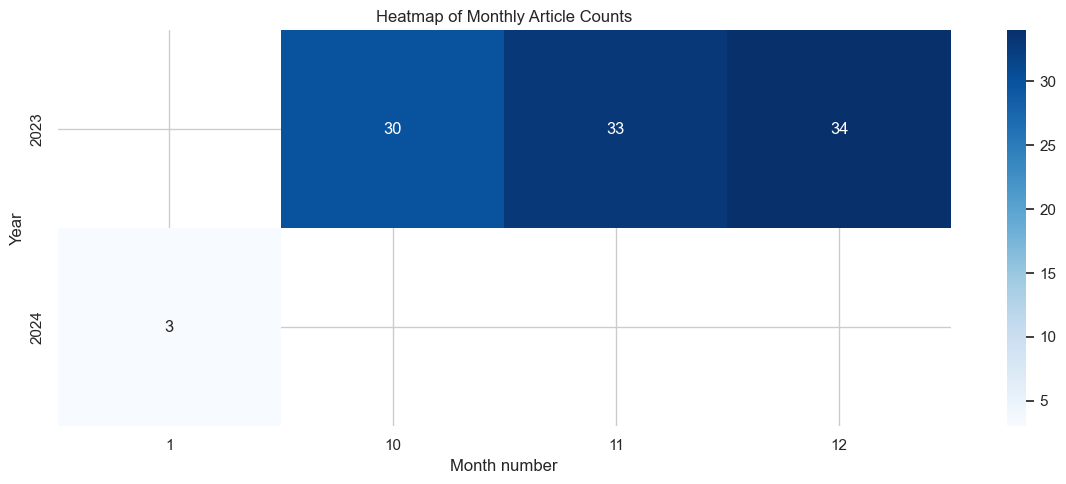

In [13]:
heatmap_df = analysis_df.copy()
heatmap_df["year"] = heatmap_df["month"].dt.year
heatmap_df["month_number"] = heatmap_df["month"].dt.month

pivot_df = heatmap_df.pivot_table(
    index="year",
    columns="month_number",
    values="article_count",
    aggfunc="mean"
)

plt.figure(figsize=(12, 5))

sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="Blues")

plt.title("Heatmap of Monthly Article Counts")
plt.xlabel("Month number")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [14]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import plotly.io as pio
pio.renderers.default = "browser"

In [16]:
import plotly.express as px

fig = px.scatter(
    analysis_df,
    x="inflation_yoy",
    y="article_count",
    color="inflation_regime",
    size="article_count",
    hover_data=["month"],
    title="Relationship between Inflation and Media Coverage"
)

fig.update_layout(
    xaxis_title="Inflation (Year-over-Year)",
    yaxis_title="Number of Articles",
)

fig.show()

In [17]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=analysis_df["month"],
    y=analysis_df["inflation_yoy"],
    mode="lines+markers",
    name="Inflation YoY",
    hovertemplate="Month: %{x}<br>Inflation YoY: %{y:.2f}%<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=analysis_df["month"],
    y=analysis_df["article_count"],
    mode="lines+markers",
    name="Article Count",
    yaxis="y2",
    hovertemplate="Month: %{x}<br>Articles: %{y}<extra></extra>"
))

fig.add_hline(
    y=None
)

fig.update_layout(
    title="Interactive Time Series: Inflation and Media Coverage",
    xaxis_title="Month",
    yaxis=dict(title="Inflation YoY (%)"),
    yaxis2=dict(
        title="Number of Articles",
        overlaying="y",
        side="right"
    ),
    hovermode="x unified"
)

fig.show()

In [18]:
# website csv 
rq7_export_df = analysis_df[
    ["month", "inflation_yoy", "article_count", "inflation_regime"]
].copy()

rq7_export_df


,month,inflation_yoy,article_count,inflation_regime
0,2023-10-01,3.788530,30,high_inflation
1,2023-11-01,3.166208,33,lower_inflation
2,2023-12-01,3.710255,34,lower_inflation
3,2024-01-01,2.887107,3,lower_inflation


In [19]:
from pathlib import Path

output_path = Path(
"/Users/ceydadut/Desktop/DataScienceProject/DataScienceProject/website/data/rq7_data.csv"
)

rq7_export_df.to_csv(output_path, index=False)